# Whisper Encoder Layer Redundancy — Analysis

RQ1: Do cosine similarity, MSE, and outlier activation metrics reliably predict encoder layer importance (as measured by ΔWER)?

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.stats as stats

plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

LANGUAGES   = ["da_dk", "en_us", "it_it", "de_de"]
LANG_LABELS = ["Danish", "English", "Italian", "German"]
NUM_LAYERS  = 32
THRESHOLD   = 0.05  # 5 % relative WER increase = "significant"

with open("results/proxy_metrics.json") as f:
    proxy = json.load(f)

with open("results/delta_wers.json") as f:
    d = json.load(f)

baseline_wers = d["baseline_wers"]
delta_wers    = np.array([d["delta_wers"][l]   for l in LANGUAGES])   # [4, 32]
layer_wers    = np.array([d["layer_wers"][l]    for l in LANGUAGES])   # [4, 32]

# proxy metric arrays  [4, 32]
cos_sim       = np.array([proxy[l]["cos_sim"]       for l in LANGUAGES])
mse           = np.array([proxy[l]["mse"]           for l in LANGUAGES])
outlier_frac  = np.array([proxy[l]["outlier_frac"]  for l in LANGUAGES])
outlier_delta = np.array([proxy[l]["outlier_delta"] for l in LANGUAGES])
amp_ratio     = np.array([proxy[l]["amp_ratio"]     for l in LANGUAGES])

mean_delta = delta_wers.mean(axis=0)   # [32] mean ΔWER across languages

print("Baseline WERs:")
for lang, label in zip(LANGUAGES, LANG_LABELS):
    print(f"  {label}: {baseline_wers[lang]:.4f}")


Baseline WERs:
  Danish: 0.2392
  English: 0.1541
  Italian: 0.1474
  German: 0.1708


## 1. ΔWER per layer

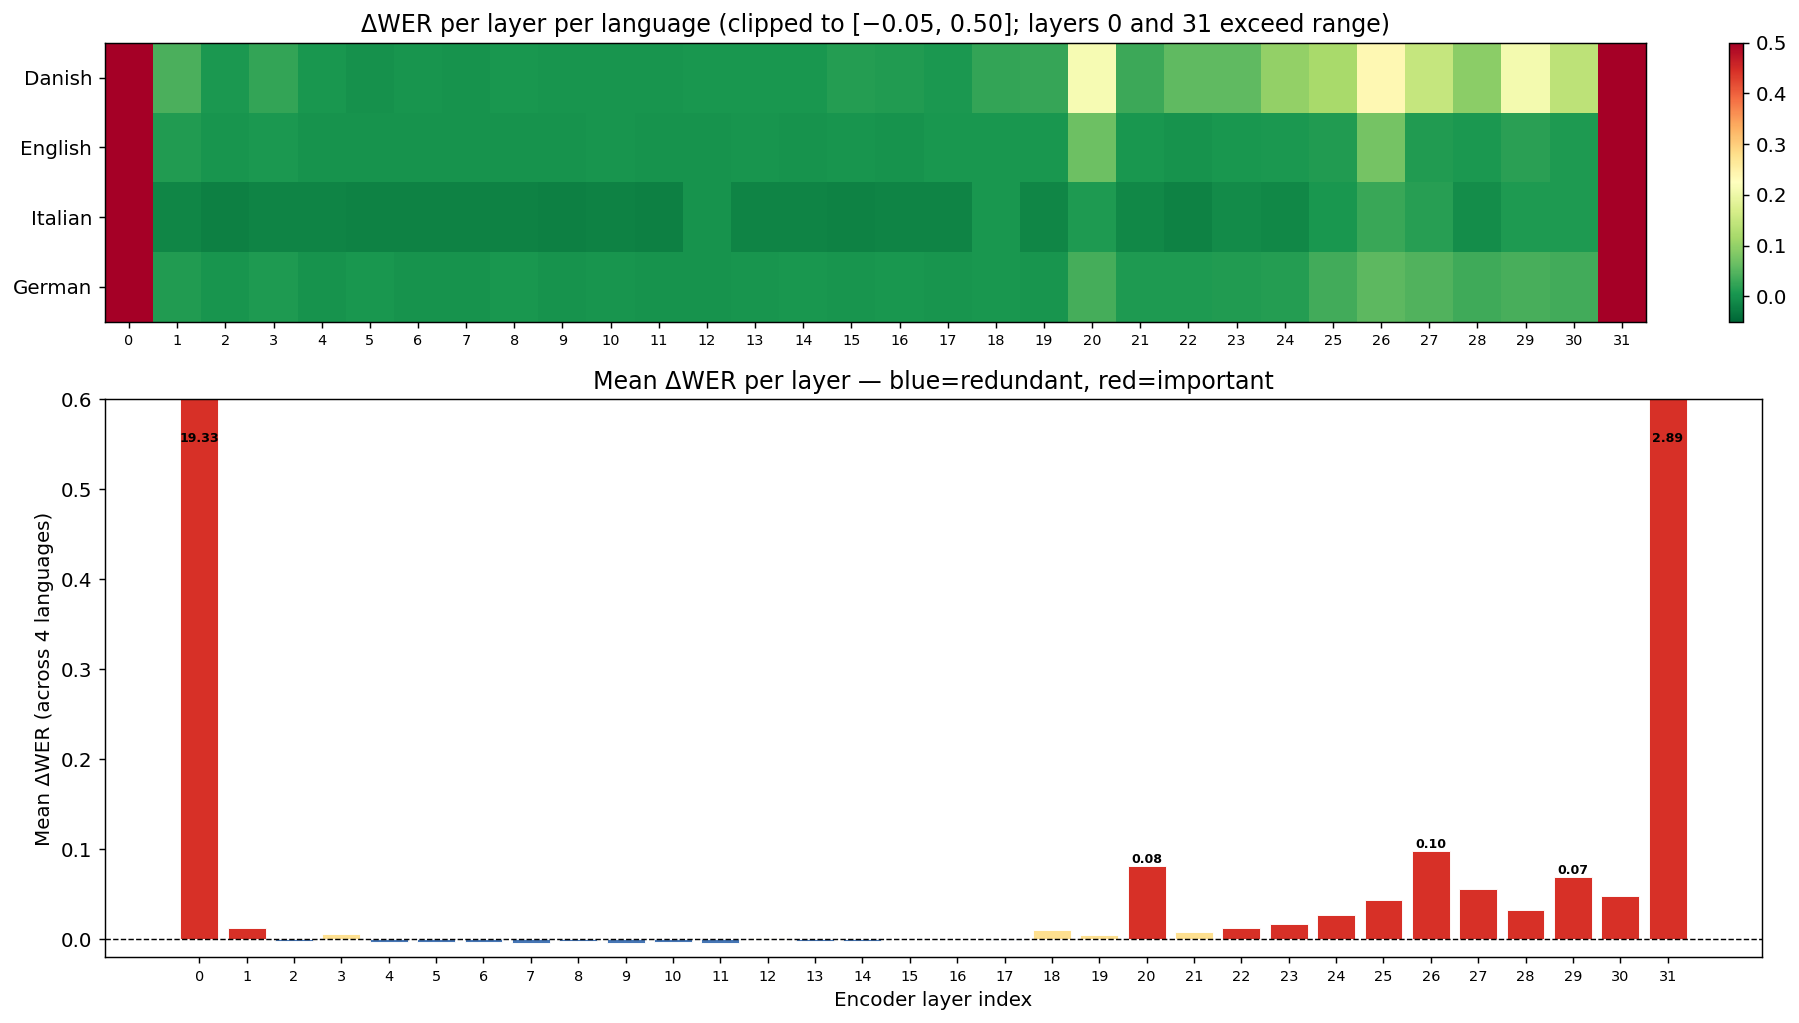

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [1, 2]})

# --- top: heatmap across languages ---
ax = axes[0]
# clip layer 0 and 31 for visualisation (they dominate the scale)
clipped = np.clip(delta_wers, -0.05, 0.5)
im = ax.imshow(clipped, aspect="auto", cmap="RdYlGn_r", vmin=-0.05, vmax=0.5)
ax.set_yticks(range(4))
ax.set_yticklabels(LANG_LABELS)
ax.set_xticks(range(NUM_LAYERS))
ax.set_xticklabels(range(NUM_LAYERS), fontsize=8)
ax.set_title("ΔWER per layer per language (clipped to [−0.05, 0.50]; layers 0 and 31 exceed range)")
plt.colorbar(im, ax=ax, fraction=0.02)

# --- bottom: mean ΔWER bar chart (log scale, exclude 0 and 31 for readability) ---
ax2 = axes[1]
layers = np.arange(NUM_LAYERS)
colors = ["#d73027" if v > 0.01 else "#4575b4" if v < 0 else "#fee090" for v in mean_delta]
bars = ax2.bar(layers, mean_delta, color=colors, edgecolor="white", linewidth=0.5)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_xlabel("Encoder layer index")
ax2.set_ylabel("Mean ΔWER (across 4 languages)")
ax2.set_title("Mean ΔWER per layer — blue=redundant, red=important")
ax2.set_xticks(layers)
ax2.set_xticklabels(layers, fontsize=8)

# annotate the big outliers
for idx in [0, 20, 26, 29, 31]:
    ax2.annotate(f"{mean_delta[idx]:.2f}", xy=(idx, min(mean_delta[idx], 0.55)),
                 ha="center", va="bottom", fontsize=7, fontweight="bold")

ax2.set_ylim(-0.02, 0.6)
plt.tight_layout()
plt.savefig("results/delta_wer_overview.png", bbox_inches="tight")
plt.show()


## 2. Proxy metrics across layers

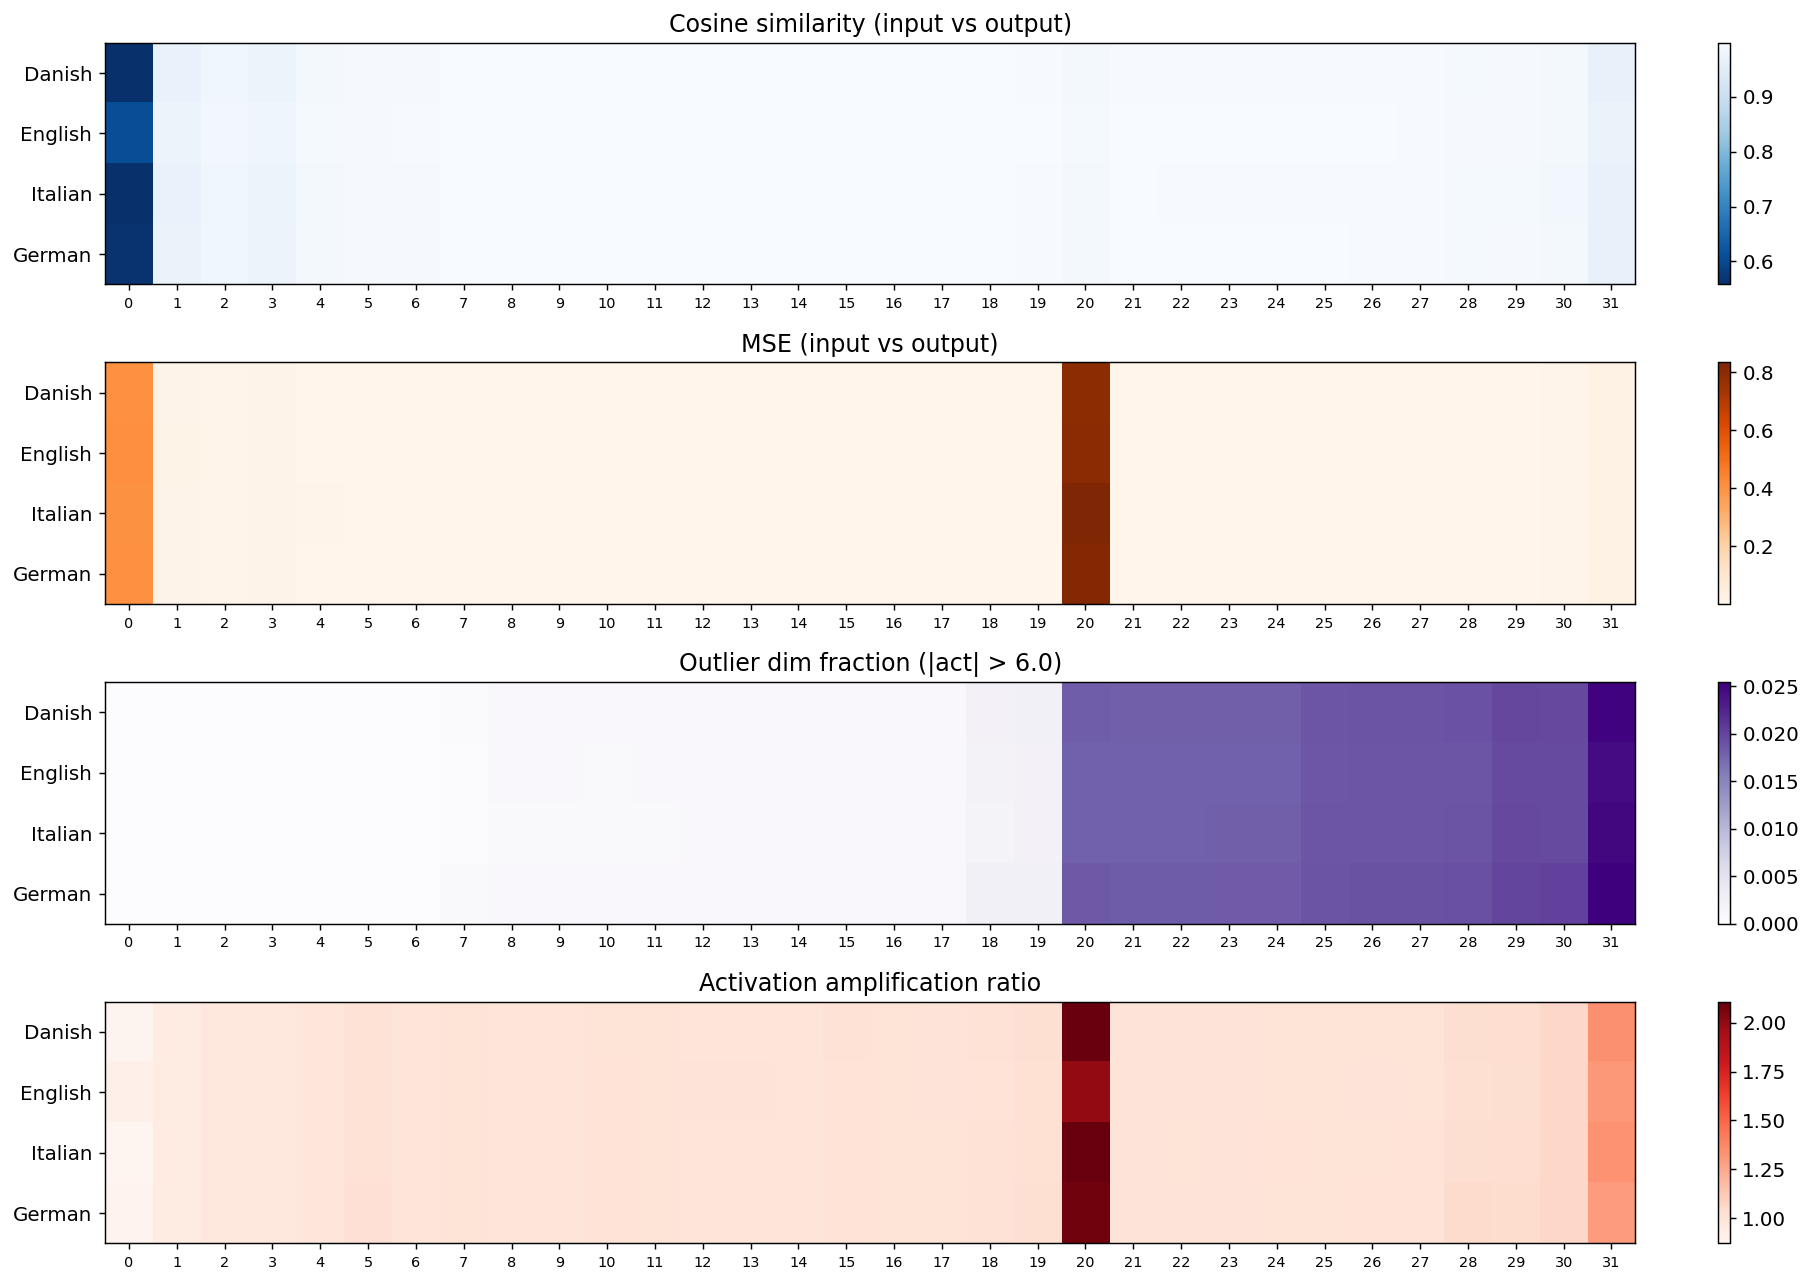

In [3]:
metrics = [
    (cos_sim,       "Cosine similarity (input vs output)",  "cos_sim",      "Blues_r"),
    (mse,           "MSE (input vs output)",                "mse",          "Oranges"),
    (outlier_frac,  "Outlier dim fraction (|act| > 6.0)",   "outlier_frac", "Purples"),
    (amp_ratio,     "Activation amplification ratio",       "amp_ratio",    "Reds"),
]

fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 10))

for ax, (data, title, _, cmap) in zip(axes, metrics):
    im = ax.imshow(data, aspect="auto", cmap=cmap)
    ax.set_yticks(range(4))
    ax.set_yticklabels(LANG_LABELS)
    ax.set_xticks(range(NUM_LAYERS))
    ax.set_xticklabels(range(NUM_LAYERS), fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.02)

plt.tight_layout()
plt.savefig("results/proxy_metrics_heatmaps.png", bbox_inches="tight")
plt.show()


## 3. Proxy metric vs ΔWER correlation (RQ1)

Spearman rank correlation between each proxy metric and ΔWER, per language and averaged across all layers.
Layer 0 is excluded from the correlation — its ΔWER (+19) is so extreme it dominates everything and makes the correlation trivially high regardless of metric quality.

In [4]:
EXCLUDE = [0, 31]  # architectural boundary layers — structurally forced to be important
keep = [i for i in range(NUM_LAYERS) if i not in EXCLUDE]

proxy_metrics = {
    "cos_sim (↓ = more change)": -cos_sim,
    "MSE":                         mse,
    "outlier_frac":                outlier_frac,
    "outlier_delta":               outlier_delta,
    "amp_ratio":                   amp_ratio,
}

print(f"Spearman ρ  vs  ΔWER  (layers {keep[0]}–{keep[-1]}, n={len(keep)}, excluding boundary layers 0 & 31)\n")
header = f"{'Metric':<30}" + "".join(f"{lb:>10}" for lb in LANG_LABELS) + f"{'Mean':>10}"
print(header)
print("-" * len(header))

corr_table = {}
for name, data in proxy_metrics.items():
    rhos = []
    for li, lang in enumerate(LANGUAGES):
        rho, _ = stats.spearmanr(data[li][keep], delta_wers[li][keep])
        rhos.append(rho)
    mean_rho = np.mean(rhos)
    corr_table[name] = rhos + [mean_rho]
    row = f"{name:<30}" + "".join(f"{r:>10.3f}" for r in rhos) + f"{mean_rho:>10.3f}"
    print(row)


Spearman ρ  vs  ΔWER  (layers 1–30, n=30, excluding boundary layers 0 & 31)

Metric                            Danish   English   Italian    German      Mean
--------------------------------------------------------------------------------
cos_sim (↓ = more change)          0.499     0.570     0.339     0.493     0.475
MSE                                0.525     0.584     0.346     0.521     0.494
outlier_frac                       0.794     0.612     0.763     0.712     0.720
outlier_delta                      0.210     0.275     0.395     0.459     0.335
amp_ratio                          0.400     0.297     0.431     0.406     0.384


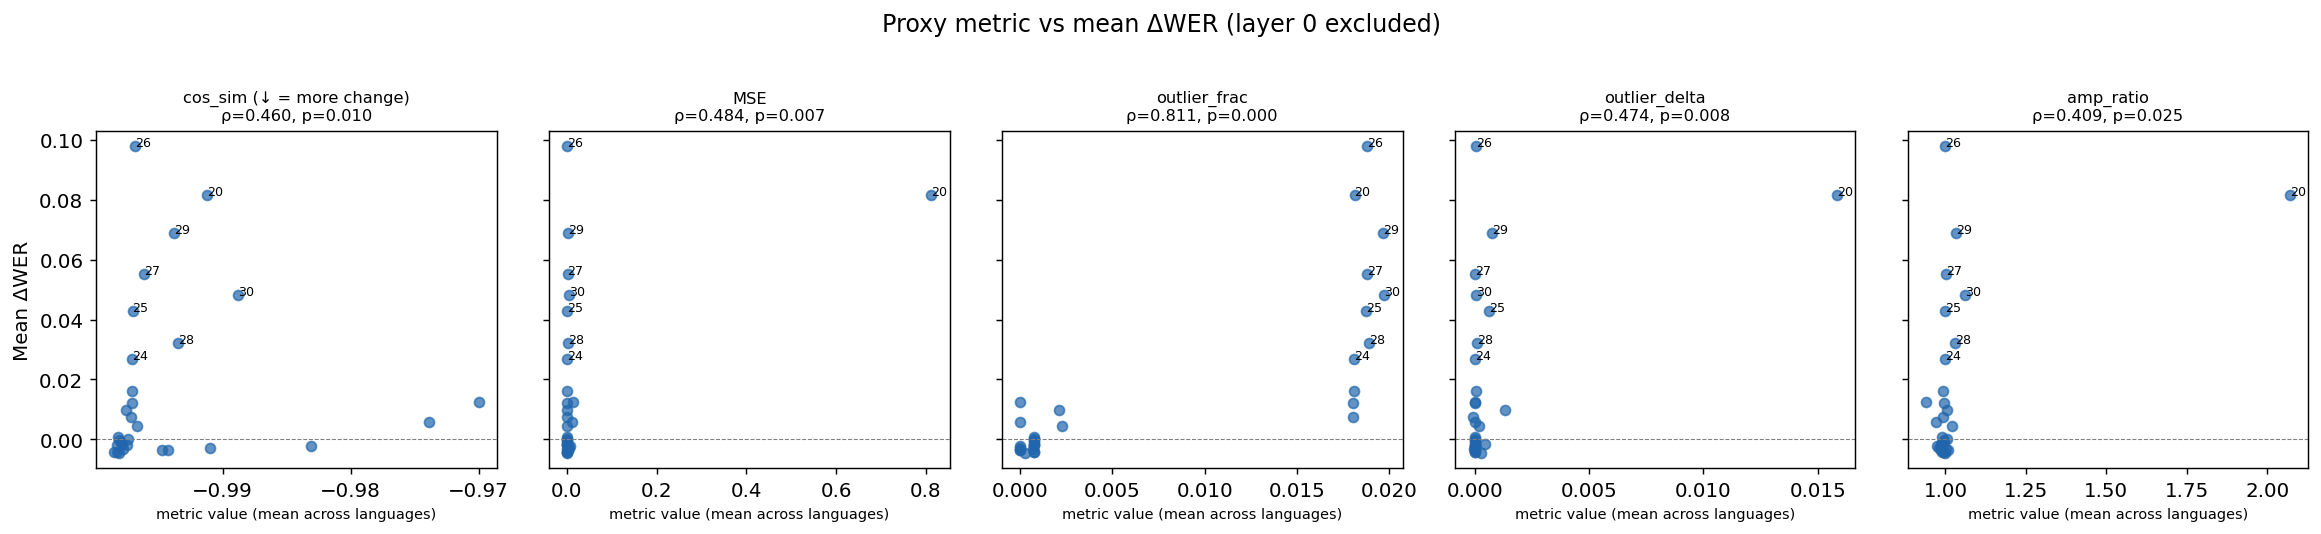

In [5]:
fig, axes = plt.subplots(1, len(proxy_metrics), figsize=(18, 4), sharey=True)

for ax, (name, data) in zip(axes, proxy_metrics.items()):
    x = data.mean(axis=0)[keep]
    y = mean_delta[keep]
    ax.scatter(x, y, s=30, alpha=0.7, color="#2166ac")
    for i, layer in enumerate(keep):
        if abs(y[i]) > 0.02 or layer in [20, 31]:
            ax.annotate(str(layer), (x[i], y[i]), fontsize=7, ha="left")
    rho, pval = stats.spearmanr(x, y)
    ax.set_title(f"{name}\nρ={rho:.3f}, p={pval:.3f}", fontsize=9)
    ax.set_xlabel("metric value (mean across languages)", fontsize=8)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")

axes[0].set_ylabel("Mean ΔWER")
plt.suptitle("Proxy metric vs mean ΔWER (layer 0 excluded)", y=1.02)
plt.tight_layout()
plt.savefig("results/proxy_vs_delta_wer.png", bbox_inches="tight")
plt.show()


## 4. Cross-language importance consistency (RQ2)

Are the same layers ranked as important across languages?

Spearman ρ of ΔWER rankings between language pairs

      Danish × English     ρ=0.923  p=0.0000
      Danish × Italian     ρ=0.864  p=0.0000
      Danish × German      ρ=0.885  p=0.0000
     English × Italian     ρ=0.816  p=0.0000
     English × German      ρ=0.835  p=0.0000
     Italian × German      ρ=0.791  p=0.0000


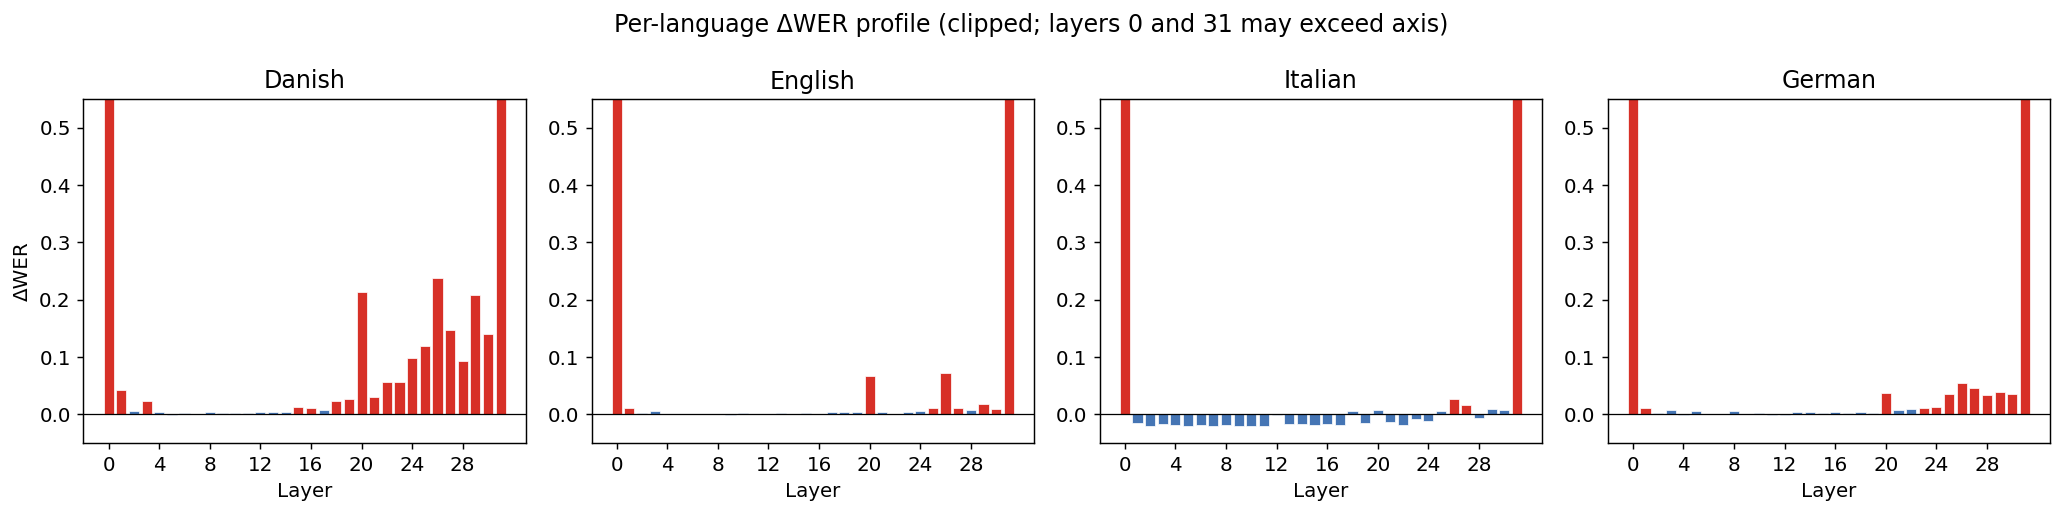

In [6]:
print("Spearman ρ of ΔWER rankings between language pairs\n")
for i, (la, la_label) in enumerate(zip(LANGUAGES, LANG_LABELS)):
    for j, (lb, lb_label) in enumerate(zip(LANGUAGES, LANG_LABELS)):
        if j <= i:
            continue
        rho, pval = stats.spearmanr(delta_wers[i], delta_wers[j])
        print(f"  {la_label:>10} × {lb_label:<10}  ρ={rho:.3f}  p={pval:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for li, (lang, label) in enumerate(zip(LANGUAGES, LANG_LABELS)):
    axes[li].bar(range(NUM_LAYERS), delta_wers[li],
                 color=["#d73027" if v > 0.01 else "#4575b4" for v in delta_wers[li]],
                 edgecolor="white", linewidth=0.4)
    axes[li].axhline(0, color="black", linewidth=0.7)
    axes[li].set_title(label)
    axes[li].set_xlabel("Layer")
    axes[li].set_xticks(range(0, NUM_LAYERS, 4))
    axes[li].set_ylim(-0.05, 0.55)

axes[0].set_ylabel("ΔWER")
plt.suptitle("Per-language ΔWER profile (clipped; layers 0 and 31 may exceed axis)")
plt.tight_layout()
plt.savefig("results/delta_wer_per_language.png", bbox_inches="tight")
plt.show()


## 5. Pruning capacity — language-agnostic prunable set (RQ3 & RQ4)

Rank layers by mean ΔWER (ascending). Remove the bottom-k layers and check whether every language stays within the 5% relative WER threshold.

In [7]:
rank_order = np.argsort(mean_delta)   # least important first
baseline_arr = np.array([baseline_wers[l] for l in LANGUAGES])  # [4]

print("Layer importance ranking (least → most important by mean ΔWER):\n")
print(f"  {'Rank':<6} {'Layer':<8} {'Mean ΔWER':>12}  {'da':>8}  {'en':>8}  {'it':>8}  {'de':>8}")
print("  " + "-" * 62)
for rank, layer in enumerate(rank_order):
    deltas = "  ".join(f"{delta_wers[li, layer]:>+8.4f}" for li in range(4))
    print(f"  {rank+1:<6} {layer:<8} {mean_delta[layer]:>+12.4f}  {deltas}")


Layer importance ranking (least → most important by mean ΔWER):

  Rank   Layer       Mean ΔWER        da        en        it        de
  --------------------------------------------------------------
  1      7             -0.0045   +0.0008   +0.0000   -0.0198   +0.0011
  2      9             -0.0043   +0.0021   -0.0003   -0.0200   +0.0012
  3      11            -0.0041   +0.0032   +0.0012   -0.0204   -0.0004
  4      5             -0.0036   -0.0008   +0.0001   -0.0195   +0.0058
  5      6             -0.0036   +0.0027   +0.0005   -0.0185   +0.0009
  6      10            -0.0031   +0.0022   +0.0017   -0.0193   +0.0029
  7      4             -0.0029   +0.0051   +0.0013   -0.0176   -0.0004
  8      2             -0.0021   +0.0062   +0.0022   -0.0204   +0.0034
  9      14            -0.0018   +0.0052   +0.0004   -0.0170   +0.0042
  10     13            -0.0017   +0.0041   +0.0017   -0.0163   +0.0036
  11     8             -0.0017   +0.0045   +0.0012   -0.0182   +0.0058
  12     17       

In [8]:
# NOTE: individual ΔWER scores are not perfectly additive when removing multiple
# layers at once. This is an approximation; Phase 4 (multi-layer sweep) will
# give the true values. Use this to identify candidates, not as final WER estimates.

cumulative_delta = np.zeros(4)   # [4 languages]
k_star = None

print(f"Cumulative estimated WER impact as k layers are removed (5% relative threshold)\n")
print(f"  {'k':<5} {'Layers removed':<30} {'max rel. ΔWER':>15}  {'within 5%?':>12}")
print("  " + "-" * 68)

for k in range(1, NUM_LAYERS):
    layer = rank_order[k - 1]
    cumulative_delta += delta_wers[:, layer]
    rel_increase = (cumulative_delta / baseline_arr).max()
    within = rel_increase <= THRESHOLD
    layers_so_far = sorted(rank_order[:k].tolist())
    label = str(layers_so_far) if k <= 12 else f"{layers_so_far[:6]}...({k} layers)"
    flag = "✓" if within else "✗  ← exceeded"
    print(f"  {k:<5} {str(layers_so_far):<30} {rel_increase:>15.3f}  {flag}")
    if k_star is None and not within:
        k_star = k - 1

print(f"\n→ Estimated k* = {k_star} layers can be removed within the 5% relative WER threshold")
print(f"  Prunable set: {sorted(rank_order[:k_star].tolist())}")
print(f"  Compression:  {NUM_LAYERS - k_star}/{NUM_LAYERS} layers retained  ({(NUM_LAYERS-k_star)/NUM_LAYERS*100:.0f}%)")


Cumulative estimated WER impact as k layers are removed (5% relative threshold)

  k     Layers removed                   max rel. ΔWER    within 5%?
  --------------------------------------------------------------------
  1     [7]                                      0.006  ✓
  2     [7, 9]                                   0.013  ✓
  3     [7, 9, 11]                               0.025  ✓
  4     [5, 7, 9, 11]                            0.045  ✓
  5     [5, 6, 7, 9, 11]                         0.050  ✗  ← exceeded
  6     [5, 6, 7, 9, 10, 11]                     0.067  ✗  ← exceeded
  7     [4, 5, 6, 7, 9, 10, 11]                  0.065  ✗  ← exceeded
  8     [2, 4, 5, 6, 7, 9, 10, 11]               0.090  ✗  ← exceeded
  9     [2, 4, 5, 6, 7, 9, 10, 11, 14]           0.111  ✗  ← exceeded
  10    [2, 4, 5, 6, 7, 9, 10, 11, 13, 14]           0.131  ✗  ← exceeded
  11    [2, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14]           0.165  ✗  ← exceeded
  12    [2, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 

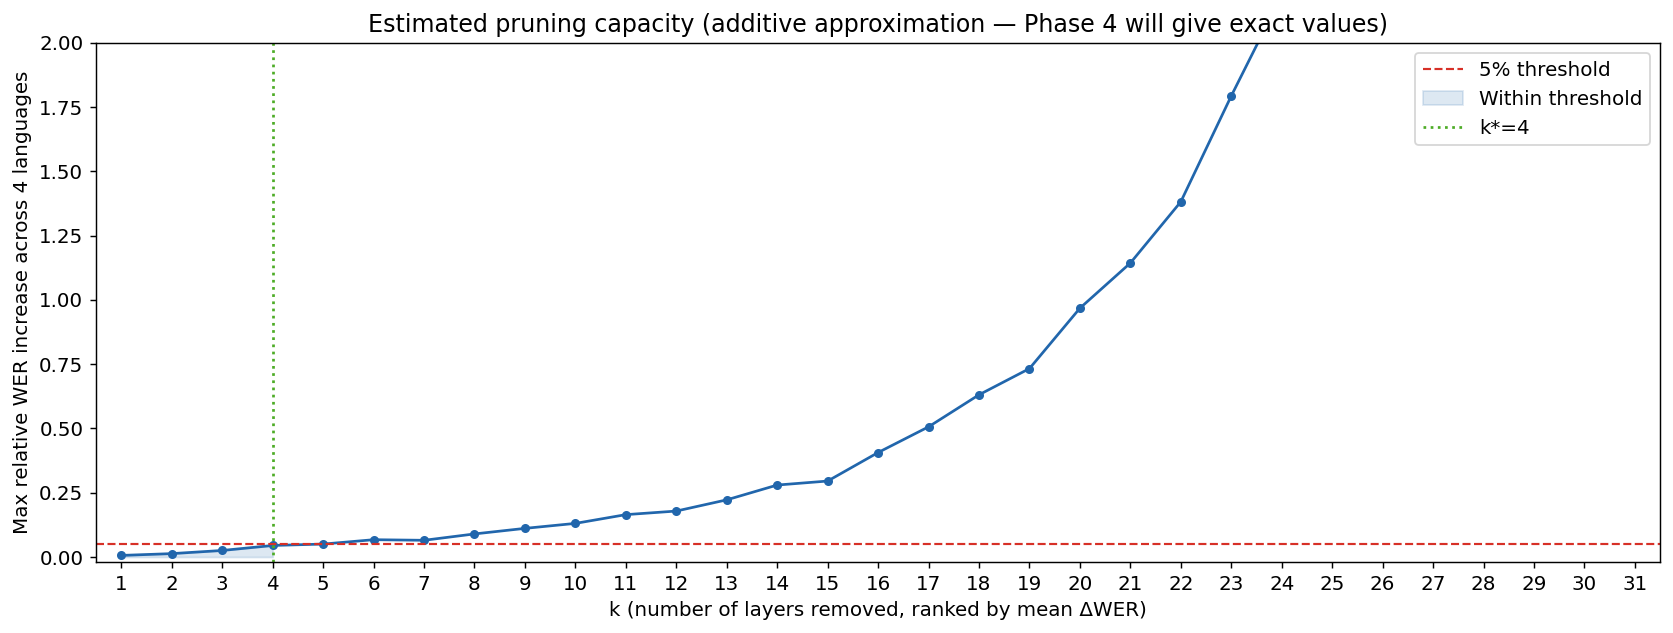

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))

cumulative_delta = np.zeros(4)
max_rel_increases = []

for k in range(1, NUM_LAYERS):
    layer = rank_order[k - 1]
    cumulative_delta += delta_wers[:, layer]
    rel_increase = (cumulative_delta / baseline_arr).max()
    max_rel_increases.append(rel_increase)

ks = np.arange(1, NUM_LAYERS)
ax.plot(ks, max_rel_increases, marker="o", markersize=4, color="#2166ac", linewidth=1.5)
ax.axhline(THRESHOLD, color="#d73027", linewidth=1.2, linestyle="--", label="5% threshold")
ax.fill_between(ks, 0, max_rel_increases,
                where=[v <= THRESHOLD for v in max_rel_increases],
                alpha=0.15, color="#2166ac", label="Within threshold")

if k_star:
    ax.axvline(k_star, color="#4dac26", linewidth=1.5, linestyle=":", label=f"k*={k_star}")

ax.set_xlabel("k (number of layers removed, ranked by mean ΔWER)")
ax.set_ylabel("Max relative WER increase across 4 languages")
ax.set_title("Estimated pruning capacity (additive approximation — Phase 4 will give exact values)")
ax.set_xticks(ks)
ax.set_xlim(0.5, NUM_LAYERS - 0.5)
ax.set_ylim(-0.02, min(max(max_rel_increases) * 1.1, 2.0))
ax.legend()
plt.tight_layout()
plt.savefig("results/pruning_capacity_estimate.png", bbox_inches="tight")
plt.show()


---
## Paper figures

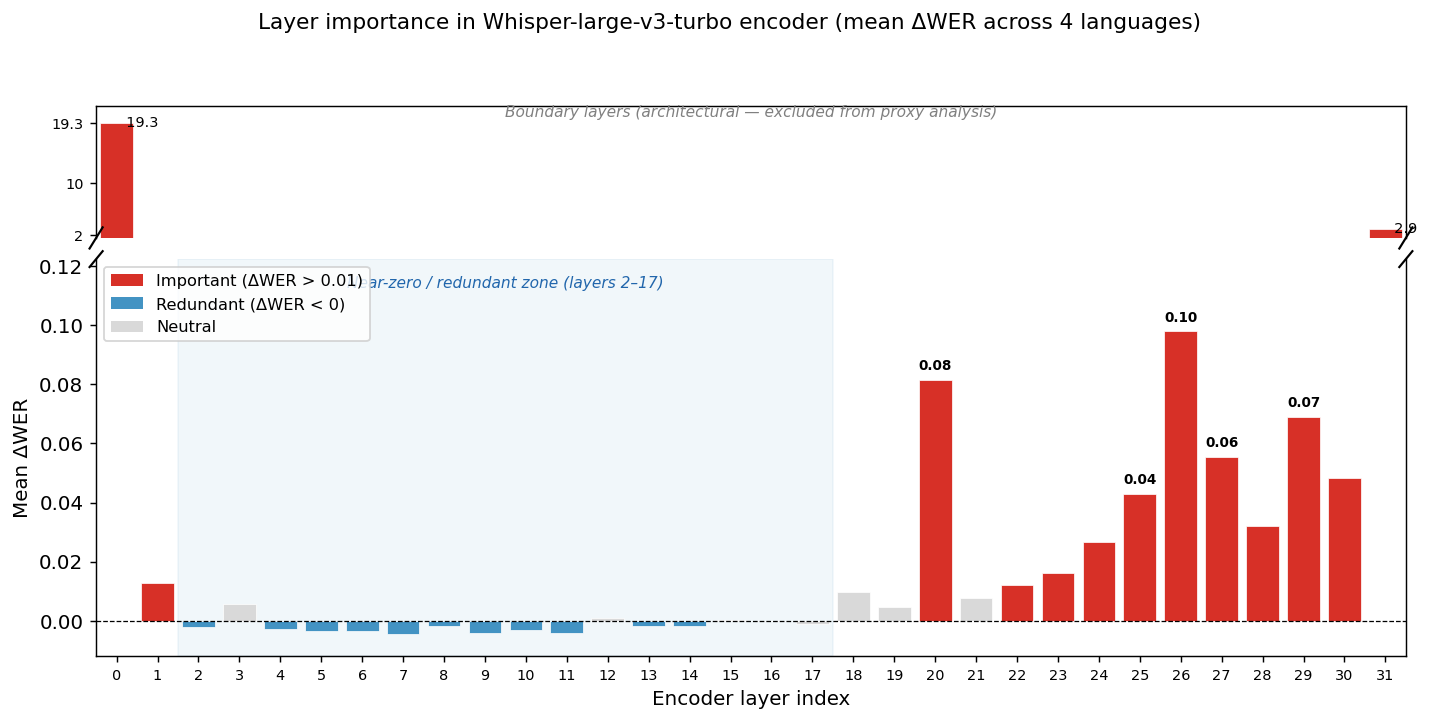

In [10]:
"""
Figure 1 — ΔWER profile (interior layers 1–30 in focus)
Broken y-axis: top strip shows layers 0 and 31 (boundary layers);
bottom panel shows layers 1–30 at full resolution.
"""
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

REDUNDANT_COLOR = "#4393c3"
IMPORTANT_COLOR = "#d73027"
NEUTRAL_COLOR   = "#d9d9d9"

layers = np.arange(NUM_LAYERS)

def bar_color(v):
    if v > 0.01:   return IMPORTANT_COLOR
    if v < -0.001: return REDUNDANT_COLOR
    return NEUTRAL_COLOR

colors = [bar_color(v) for v in mean_delta]

fig = plt.figure(figsize=(13, 5.5))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.08)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1])

# --- top: boundary layers 0 and 31 only ---
extreme_vals = np.zeros(NUM_LAYERS)
extreme_vals[[0, 31]] = mean_delta[[0, 31]]
ax_top.bar(layers, extreme_vals, color=colors, edgecolor="white", linewidth=0.4, width=0.8)
ax_top.set_ylim(1.5, 22)
ax_top.set_yticks([2, 10, 19.3])
ax_top.set_yticklabels(["2", "10", "19.3"], fontsize=8)
ax_top.set_xlim(-0.5, 31.5)
ax_top.set_xticks([])
ax_top.spines["bottom"].set_visible(False)
ax_top.tick_params(bottom=False)
kw = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1.2)
ax_top.plot((-0.005, 0.005), (-0.08,  0.08), **kw)
ax_top.plot((0.995,  1.005), (-0.08,  0.08), **kw)
ax_top.text(0,  19.3, "  19.3", va="center", fontsize=8)
ax_top.text(31, 2.9,  "  2.9",  va="center", fontsize=8)
ax_top.text(0.5, 0.92, "Boundary layers (architectural — excluded from proxy analysis)",
            transform=ax_top.transAxes, ha="center", fontsize=8.5,
            color="grey", style="italic")

# --- bottom: interior layers 1–30 ---
interior_vals = mean_delta.copy()
interior_vals[[0, 31]] = 0
ax_bot.bar(layers, interior_vals, color=colors, edgecolor="white", linewidth=0.4, width=0.8)
ax_bot.axhline(0, color="black", linewidth=0.7, linestyle="--")

# focus y-axis on the interior range
interior_max = np.max(np.abs(mean_delta[1:31])) * 1.25
ax_bot.set_ylim(-0.012, interior_max)
ax_bot.set_xlim(-0.5, 31.5)
ax_bot.set_xticks(layers)
ax_bot.set_xticklabels(layers, fontsize=8)
ax_bot.set_xlabel("Encoder layer index", fontsize=11)
ax_bot.set_ylabel("Mean ΔWER", fontsize=11)
ax_bot.spines["top"].set_visible(False)
kw = dict(transform=ax_bot.transAxes, color="k", clip_on=False, linewidth=1.2)
ax_bot.plot((-0.005, 0.005), (0.98, 1.02), **kw)
ax_bot.plot((0.995,  1.005), (0.98, 1.02), **kw)

# annotate notable interior layers
for idx in [20, 26, 29, 25, 27]:
    ax_bot.text(idx, mean_delta[idx] + interior_max * 0.02,
                f"{mean_delta[idx]:.2f}", ha="center", va="bottom",
                fontsize=7.5, fontweight="bold")

# shaded redundant zone
ax_bot.axvspan(1.5, 17.5, alpha=0.07, color=REDUNDANT_COLOR, zorder=0)
ax_bot.text(9.5, interior_max * 0.92, "Near-zero / redundant zone (layers 2–17)",
            ha="center", fontsize=8.5, color="#2166ac", style="italic")

legend_elements = [
    Patch(facecolor=IMPORTANT_COLOR, label="Important (ΔWER > 0.01)"),
    Patch(facecolor=REDUNDANT_COLOR, label="Redundant (ΔWER < 0)"),
    Patch(facecolor=NEUTRAL_COLOR,   label="Neutral"),
]
ax_bot.legend(handles=legend_elements, fontsize=9, loc="upper left")

fig.suptitle("Layer importance in Whisper-large-v3-turbo encoder (mean ΔWER across 4 languages)",
             fontsize=12, y=1.01)
plt.savefig("results/fig1_delta_wer_profile.pdf", bbox_inches="tight")
plt.savefig("results/fig1_delta_wer_profile.png", bbox_inches="tight", dpi=200)
plt.show()


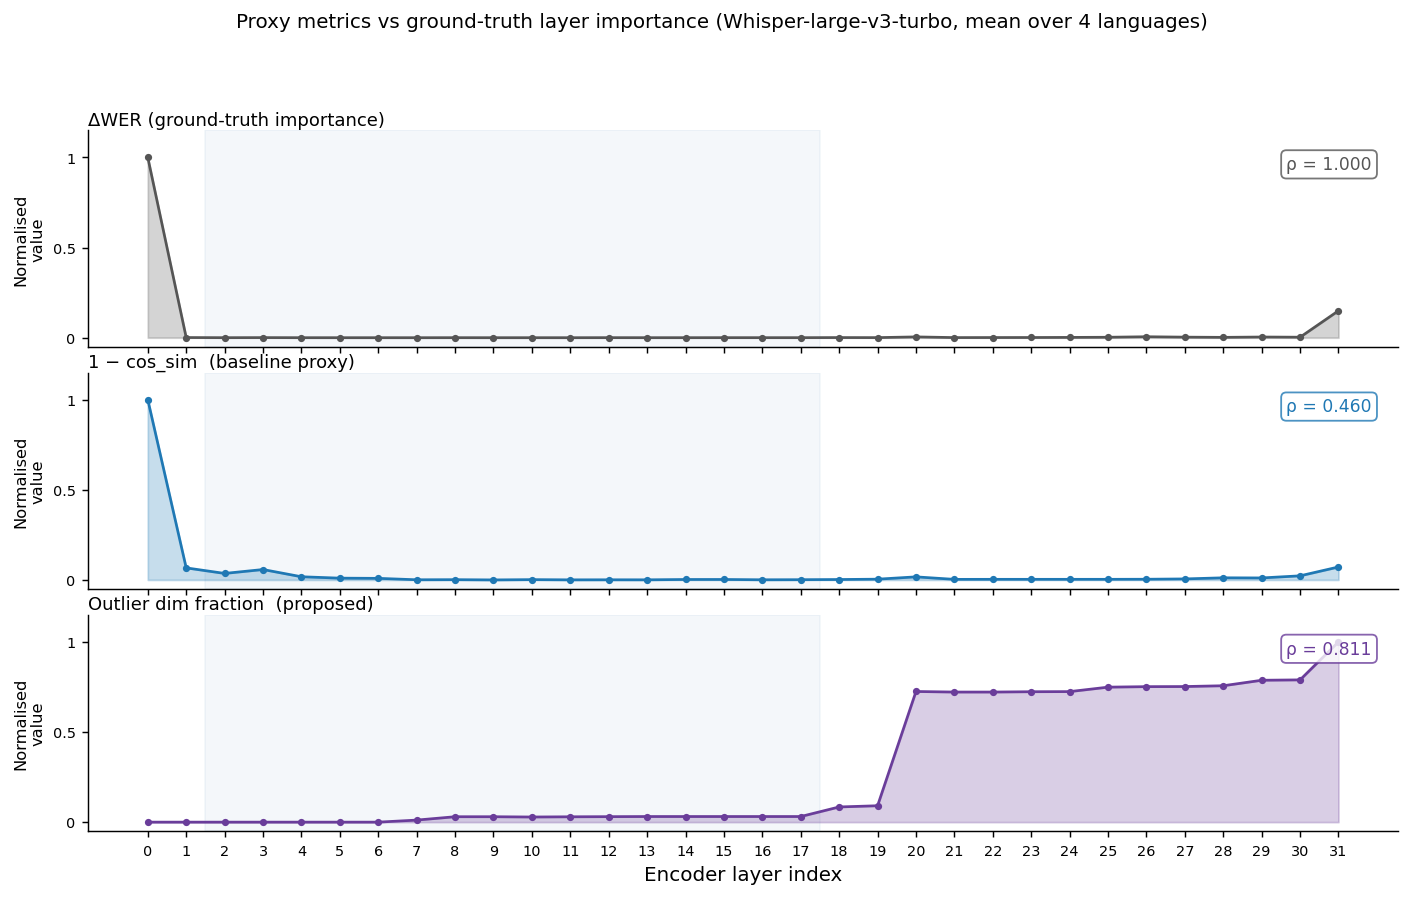

In [11]:
"""
Figure 2 — Proxy metric comparison
Three stacked panels (ΔWER / 1−cos_sim / outlier_frac) on the same x-axis,
with each metric normalised to [0,1] so shapes are directly comparable.
"""
def norm01(x):
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-12)

mean_cos_sim      = cos_sim.mean(axis=0)
mean_outlier_frac = outlier_frac.mean(axis=0)
mean_amp_ratio    = amp_ratio.mean(axis=0)

panels = [
    (mean_delta,                     "ΔWER (ground-truth importance)",    "#555555"),
    (1 - mean_cos_sim,               "1 − cos_sim  (baseline proxy)",     "#1f78b4"),
    (mean_outlier_frac,              "Outlier dim fraction  (proposed)",  "#6a3d9a"),
]

fig, axes = plt.subplots(len(panels), 1, figsize=(13, 7), sharex=True)
fig.subplots_adjust(hspace=0.12)

for ax, (data, title, color) in zip(axes, panels):
    normed = norm01(data)
    ax.fill_between(layers, normed, alpha=0.25, color=color)
    ax.plot(layers, normed, color=color, linewidth=1.5, marker="o", markersize=3)
    ax.set_ylabel("Normalised\nvalue", fontsize=9)
    ax.set_ylim(-0.05, 1.15)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "0.5", "1"], fontsize=8)
    ax.axvspan(1.5, 17.5, alpha=0.06, color="steelblue", zorder=0)
    ax.set_title(title, fontsize=10, loc="left", pad=3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    rho, _ = stats.spearmanr(norm01(data)[keep], norm01(mean_delta)[keep])
    ax.text(0.98, 0.82, f"ρ = {rho:.3f}", transform=ax.transAxes,
            ha="right", fontsize=9.5, color=color,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.8))

axes[-1].set_xlabel("Encoder layer index", fontsize=11)
axes[-1].set_xticks(layers)
axes[-1].set_xticklabels(layers, fontsize=8)

fig.suptitle("Proxy metrics vs ground-truth layer importance (Whisper-large-v3-turbo, mean over 4 languages)",
             fontsize=11, y=1.01)
plt.savefig("results/fig2_proxy_comparison.pdf", bbox_inches="tight")
plt.savefig("results/fig2_proxy_comparison.png", bbox_inches="tight", dpi=200)
plt.show()


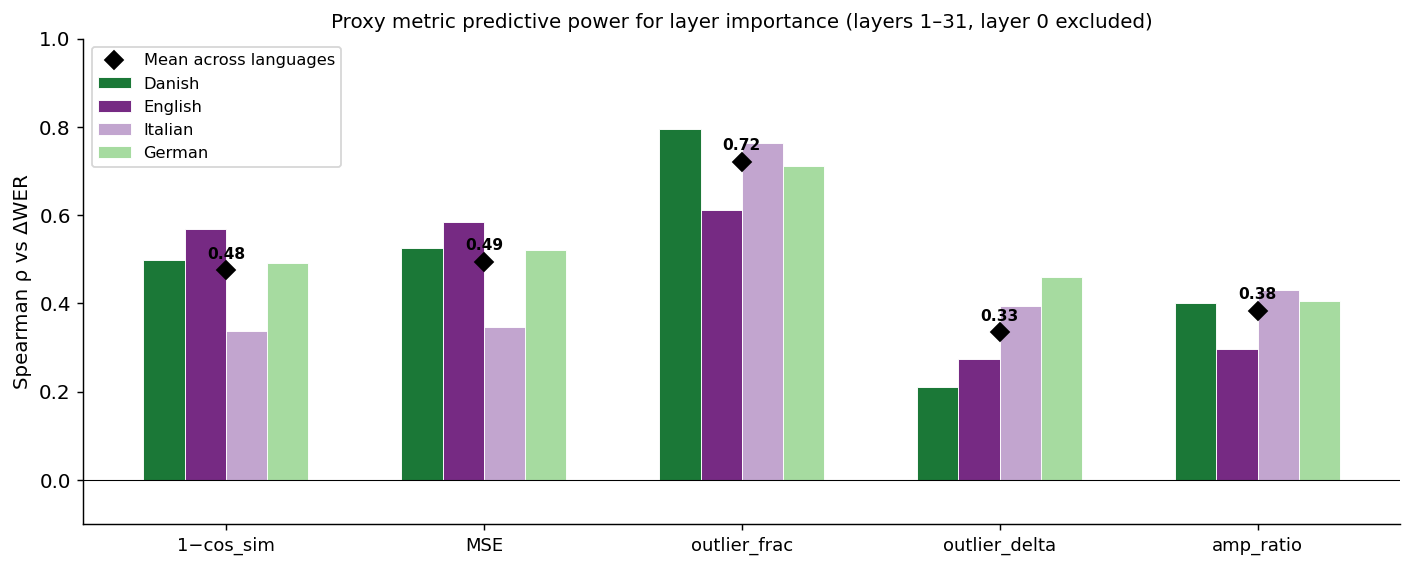

In [12]:
"""
Figure 3 — Spearman ρ grouped bar chart
All five proxy metrics × four languages, with the mean shown as a black diamond.
"""
metric_names   = ["cos_sim", "MSE", "outlier_frac", "outlier_delta", "amp_ratio"]
metric_labels  = ["1−cos_sim", "MSE", "outlier_frac", "outlier_delta", "amp_ratio"]
metric_data    = [-cos_sim, mse, outlier_frac, outlier_delta, amp_ratio]
lang_colors    = ["#1b7837", "#762a83", "#c2a5cf", "#a6dba0"]

n_metrics = len(metric_names)
n_langs   = len(LANGUAGES)
x         = np.arange(n_metrics)
width     = 0.16

fig, ax = plt.subplots(figsize=(11, 4.5))

for li, (lang, label, color) in enumerate(zip(LANGUAGES, LANG_LABELS, lang_colors)):
    rhos = []
    for data in metric_data:
        rho, _ = stats.spearmanr(data[li][keep], delta_wers[li][keep])
        rhos.append(rho)
    offset = (li - n_langs / 2 + 0.5) * width
    ax.bar(x + offset, rhos, width, label=label, color=color, edgecolor="white", linewidth=0.5)

# mean across languages as black diamond
mean_rhos = []
for data in metric_data:
    rhos_all = [stats.spearmanr(data[li][keep], delta_wers[li][keep])[0] for li in range(n_langs)]
    mean_rhos.append(np.mean(rhos_all))

ax.plot(x, mean_rhos, "kD", markersize=7, zorder=5, label="Mean across languages")
for xi, rho in zip(x, mean_rhos):
    ax.text(xi, rho + 0.02, f"{rho:.2f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=10)
ax.set_ylabel("Spearman ρ vs ΔWER", fontsize=11)
ax.set_ylim(-0.1, 1.0)
ax.set_title("Proxy metric predictive power for layer importance (layers 1–31, layer 0 excluded)", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("results/fig3_spearman_comparison.pdf", bbox_inches="tight")
plt.savefig("results/fig3_spearman_comparison.png", bbox_inches="tight", dpi=200)
plt.show()


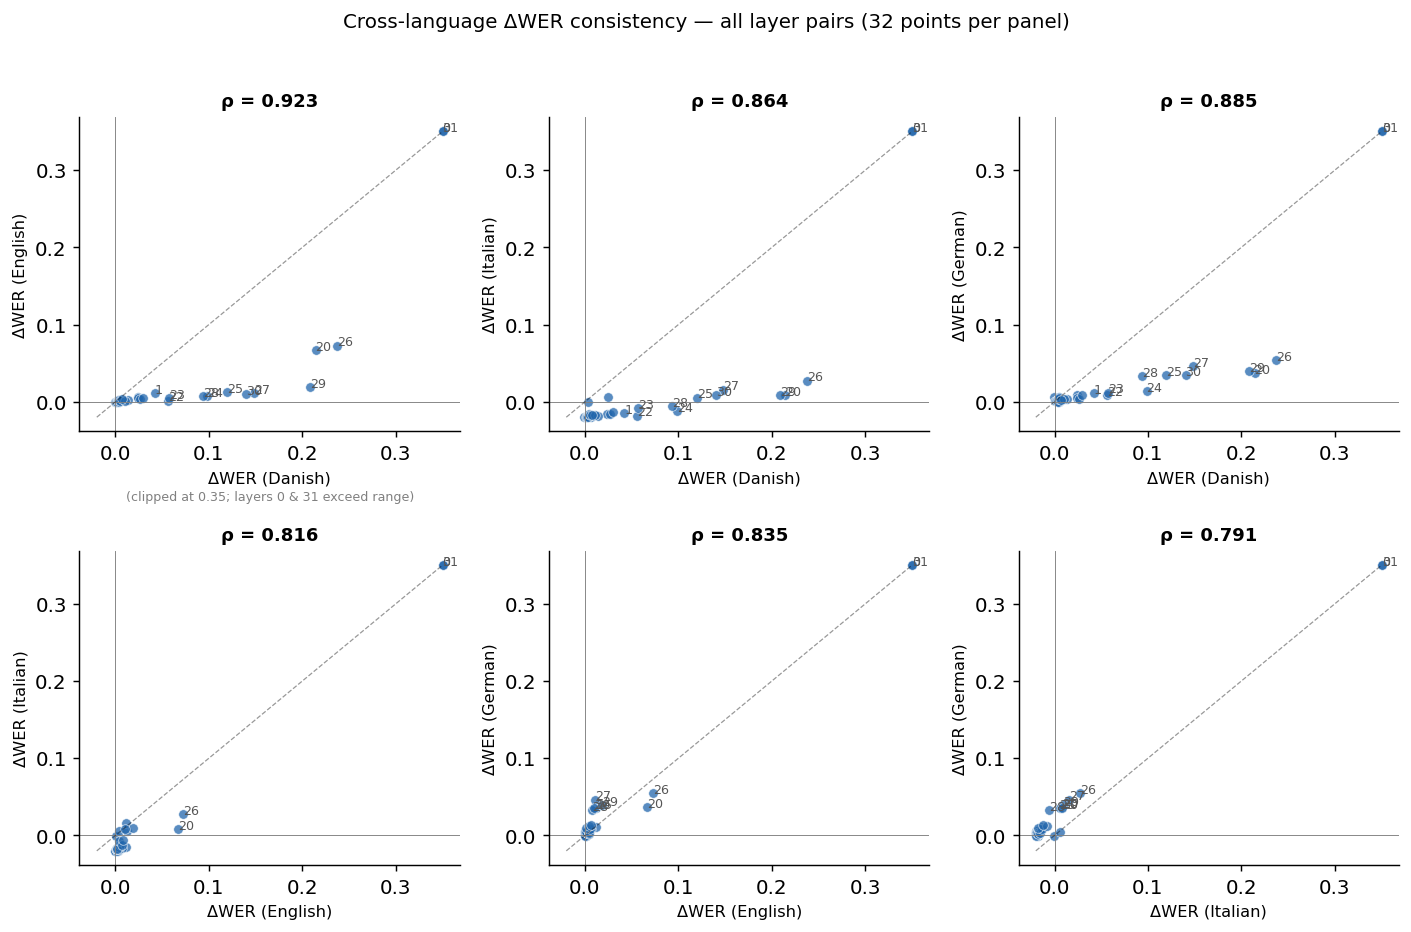

In [13]:
"""
Figure 4 — Cross-language consistency
Scatter matrix of per-language ΔWER rankings, with Spearman ρ annotated.
"""
pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
axes = axes.flatten()

for ax, (i, j) in zip(axes, pairs):
    xi = delta_wers[i]
    xj = delta_wers[j]
    rho, _ = stats.spearmanr(xi, xj)

    # clip for readability — layers 0 and 31 are extreme
    clip = 0.35
    ax.scatter(np.clip(xi, -0.02, clip), np.clip(xj, -0.02, clip),
               s=28, alpha=0.75, color="#2166ac", edgecolors="white", linewidths=0.4)

    # label notable layers
    for li in range(NUM_LAYERS):
        if abs(xi[li]) > 0.03 or abs(xj[li]) > 0.03:
            ax.annotate(str(li), (min(xi[li], clip), min(xj[li], clip)),
                        fontsize=7, ha="left", color="#555555")

    ax.axhline(0, color="grey", linewidth=0.5)
    ax.axvline(0, color="grey", linewidth=0.5)
    ax.plot([-0.02, clip], [-0.02, clip], "k--", linewidth=0.7, alpha=0.4)
    ax.set_xlabel(f"ΔWER ({LANG_LABELS[i]})", fontsize=9)
    ax.set_ylabel(f"ΔWER ({LANG_LABELS[j]})", fontsize=9)
    ax.set_title(f"ρ = {rho:.3f}", fontsize=10, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    note = "(clipped at 0.35; layers 0 & 31 exceed range)" if (i,j)==(0,1) else ""
    if note:
        ax.text(0.5, -0.22, note, transform=ax.transAxes, ha="center",
                fontsize=7, color="grey")

fig.suptitle("Cross-language ΔWER consistency — all layer pairs (32 points per panel)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("results/fig4_cross_language.pdf", bbox_inches="tight")
plt.savefig("results/fig4_cross_language.png", bbox_inches="tight", dpi=200)
plt.show()
